In [5]:
!pip install sentence-transformers scikit-learn tqdm

Extracting all files from the ZIP file, uploaded into the Google Colab

In [6]:
import tarfile
import os

dataset_path = "/content/20_newsgroups.tar.gz"
extract_path = "/content/20_newsgroups"

with tarfile.open(dataset_path, "r:gz") as tar:
    tar.extractall(path="/content")

print("Dataset extracted.")

/tmp/ipykernel_717/717959863.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


Dataset extracted.


Listing the files in the extracted source

In [7]:
os.listdir("/content/20_newsgroups")

['comp.sys.mac.hardware',
 'sci.med',
 'comp.os.ms-windows.misc',
 'rec.sport.baseball',
 'rec.autos',
 'rec.sport.hockey',
 'sci.space',
 'talk.religion.misc',
 'soc.religion.christian',
 'comp.sys.ibm.pc.hardware',
 'comp.windows.x',
 'sci.crypt',
 'talk.politics.mideast',
 'talk.politics.misc',
 'rec.motorcycles',
 'misc.forsale',
 'comp.graphics',
 'sci.electronics',
 'alt.atheism',
 'talk.politics.guns']

We load all the file text/content into the memory with their file paths

In [8]:
from pathlib import Path

data_dir = Path("/content/20_newsgroups")

texts = []
file_paths = []

for category in data_dir.iterdir():
    if category.is_dir():
        for file in category.iterdir():
            try:
                text = file.read_text(errors="ignore")
                texts.append(text)
                file_paths.append(str(file))
            except:
                pass

print("Total documents:", len(texts))

Total documents: 19997


Here, we clean/pre-process the data before training on it. We remove specifics from the content like email ID, names that are generally following "From:" aslo we remove organizations, subject contents , along with quoted content. We also remove multiple spaces to one space by using the Regular Expression in-built func. for substituting particular structure of text

In [9]:
import re

def clean_text(text):

    # remove email headers
    text = re.sub(r"From:.*\n", "", text)
    text = re.sub(r"Subject:.*\n", "", text)
    text = re.sub(r"Organization:.*\n", "", text)
    text = re.sub(r"Lines:.*\n", "", text)

    # remove quoted replies
    text = re.sub(r">+.*\n", "", text)

    # remove "In article ..."
    text = re.sub(r"In article .*", "", text)

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

Testing the pre-processing effects with an example case

In [10]:
cleaned_texts = [clean_text(t) for t in texts]

print(cleaned_texts[0][:500])

Newsgroups: comp.sys.mac.hardware Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!uwm.edu!ux1.cso.uiuc.edu!newsrelay.iastate.edu!news.iastate.edu!kmradke Message-ID: <C5yGDq.6MI@news.iastate.eduSender: news@news.iastate.edu (USENET News System) Distribution: usa Date: Fri, 23 Apr 1993 21:15:19 GMT I need help identifying this board that I found stuffed away in a corner. As the title says, all that is printed on it is NATIONA


Here, we convert all text to it's semantic vector using pre-trained transformers of Hugging Face

In [11]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    cleaned_texts,
    show_progress_bar=True,
    batch_size=64
)

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Embedding shape: (19997, 384)


We use Gaussian Mixture Model for Soft margin clustering/ probabilistic clustering. Then to decide on the number of clusters to be grouped into, we use K with lowest Bayesian Information Criterion BIC score to find out the K that fits the data efficiently with out overfitting

In [13]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

cluster_range = range(10, 31)
bics = []

for k in cluster_range:
    print("Testing clusters:", k)

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(embeddings)

    bics.append(gmm.bic(embeddings))

best_k = cluster_range[np.argmin(bics)]

print("Best cluster number:", best_k)

Testing clusters: 10
Testing clusters: 11
Testing clusters: 12
Testing clusters: 13
Testing clusters: 14
Testing clusters: 15
Testing clusters: 16
Testing clusters: 17
Testing clusters: 18
Testing clusters: 19
Testing clusters: 20
Testing clusters: 21
Testing clusters: 22
Testing clusters: 23
Testing clusters: 24
Testing clusters: 25
Testing clusters: 26
Testing clusters: 27
Testing clusters: 28
Testing clusters: 29
Testing clusters: 30
Best cluster number: 10


We plot the result of comparision of the number of clusters that is apt for the data given

We can see that K=10 has the lowest BIC score in the choosen range. so we use that for clustering

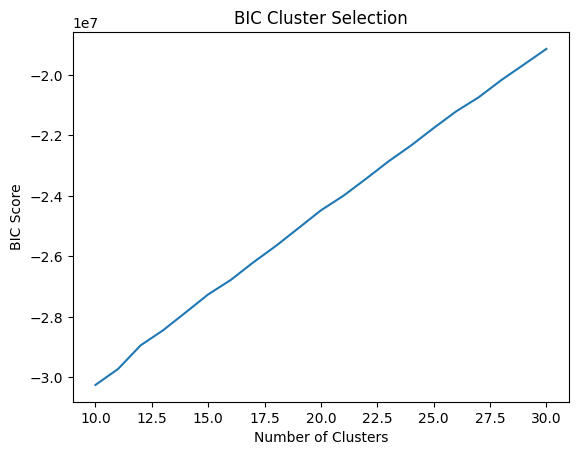

In [14]:
plt.plot(cluster_range, bics)
plt.xlabel("Number of Clusters")
plt.ylabel("BIC Score")
plt.title("BIC Cluster Selection")
plt.show()

We cluster the GMM with the K attained earlier

In [15]:
best_clusters = best_k

gmm = GaussianMixture(
    n_components=best_clusters,
    covariance_type="full",
    random_state=42
)

gmm.fit(embeddings)

print("GMM trained")

GMM trained


In [16]:
cluster_probs = gmm.predict_proba(embeddings)

print(cluster_probs.shape)

(19997, 10)


In [17]:
dominant_clusters = np.argmax(cluster_probs, axis=1)

print(dominant_clusters[:10])

[3 3 3 3 7 3 3 3 3 5]


In [18]:
ivf_index = {}

for cluster_id in range(best_clusters):
    ivf_index[cluster_id] = []

for idx, cluster_id in enumerate(dominant_clusters):
    ivf_index[cluster_id].append(embeddings[idx])

# convert to numpy arrays
for k in ivf_index:
    ivf_index[k] = np.array(ivf_index[k])

print("Clusters created:", len(ivf_index))

Clusters created: 10


In [19]:
for k in ivf_index:
    print("Cluster", k, "size:", len(ivf_index[k]))

Cluster 0 size: 1752
Cluster 1 size: 2935
Cluster 2 size: 924
Cluster 3 size: 2405
Cluster 4 size: 1006
Cluster 5 size: 2802
Cluster 6 size: 2184
Cluster 7 size: 1941
Cluster 8 size: 3080
Cluster 9 size: 968


In [20]:
centroids = gmm.means_

print("Centroid shape:", centroids.shape)

Centroid shape: (10, 384)


In [21]:
import pickle

data = {
    "embeddings": embeddings,
    "texts": cleaned_texts,
    "centroids": centroids,
    "ivf_index": ivf_index,
    "cluster_ids": dominant_clusters
}

with open("search_index.pkl", "wb") as f:
    pickle.dump(data, f)

print("Index saved")

Index saved
